In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install opencv-python pillow tqdm


In [6]:
import os
import json
import numpy as np
import cv2
from tqdm import tqdm

BASE_DIR = "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles"
SPLITS = ["train", "val", "primary_test"]

def json_to_mask(json_path, image_path, out_mask_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return

    h, w = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    for shape in data.get("shapes", []):
        if shape.get("label") != "oil":
            continue
        pts = np.array(shape["points"], dtype=np.int32)
        cv2.fillPoly(mask, [pts], 1)

    cv2.imwrite(out_mask_path, mask)

for split in SPLITS:
    images_dir = os.path.join(BASE_DIR, split, "images")
    ann_dir = os.path.join(BASE_DIR, split, "annotations")
    masks_dir = os.path.join(BASE_DIR, split, "masks")

    os.makedirs(masks_dir, exist_ok=True)

    json_files = [f for f in os.listdir(ann_dir) if f.endswith(".json")]

    print(f"\n🔄 Processing {split}")
    for jf in tqdm(json_files):
        img_name = jf.replace(".json", ".png")

        json_path = os.path.join(ann_dir, jf)
        image_path = os.path.join(images_dir, img_name)
        mask_path = os.path.join(masks_dir, img_name)

        if not os.path.exists(image_path):
            continue

        json_to_mask(json_path, image_path, mask_path)

    print(f"✅ Masks saved to {masks_dir}")



🔄 Processing train


100%|██████████| 246/246 [01:06<00:00,  3.72it/s]


✅ Masks saved to /content/drive/MyDrive/oil_spill_project/data/sentinel/tiles/train/masks

🔄 Processing val


100%|██████████| 76/76 [00:50<00:00,  1.51it/s]


✅ Masks saved to /content/drive/MyDrive/oil_spill_project/data/sentinel/tiles/val/masks

🔄 Processing primary_test


100%|██████████| 75/75 [01:30<00:00,  1.20s/it]

✅ Masks saved to /content/drive/MyDrive/oil_spill_project/data/sentinel/tiles/primary_test/masks


In [7]:
import os

BASE = "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles"
splits = ["train", "val", "primary_test"]

for s in splits:
    img_dir = os.path.join(BASE, s, "images")
    mask_dir = os.path.join(BASE, s, "masks")

    imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
    masks = sorted([f for f in os.listdir(mask_dir) if f.endswith(".png")])

    print(f"\n{s.upper()}")
    print("Images:", len(imgs))
    print("Masks :", len(masks))

    missing = set(imgs) - set(masks)
    if missing:
        print("⚠️ Missing masks for:", list(missing)[:3])
    else:
        print("✅ All images have masks")



TRAIN
Images: 4041
Masks : 246
⚠️ Missing masks for: ['aug12_01926.png', 'aug09_02915.png', 'aug09_02978.png']

VAL
Images: 865
Masks : 76
⚠️ Missing masks for: ['aug09_01229.png', 'aug09_00293.png', 'aug12_02477.png']

PRIMARY_TEST
Images: 868
Masks : 75
⚠️ Missing masks for: ['aug12_00148.png', 'aug12_00504.png', 'aug09_02311.png']


In [14]:
import os

BASE = "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles"
splits = ["train", "val", "primary_test"]

for s in splits:
    img_dir = os.path.join(BASE, s, "images")
    mask_dir = os.path.join(BASE, s, "masks")

    masks = sorted(os.listdir(mask_dir))
    images = sorted(os.listdir(img_dir))

    matched = [m for m in masks if m in images]

    print(f"\n{s.upper()}")
    print("Annotated images:", len(matched))
    print("Masks:", len(masks))



TRAIN
Annotated images: 246
Masks: 246

VAL
Annotated images: 76
Masks: 76

PRIMARY_TEST
Annotated images: 75
Masks: 75


In [12]:
import cv2
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles"
splits = ["train", "val", "primary_test"]

for split in splits:
    mask_dir = os.path.join(BASE_DIR, split, "masks")

    oil_masks = 0
    total = 0

    for f in os.listdir(mask_dir):
        if not f.endswith(".png"):
            continue

        m = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue

        total += 1
        if np.any(m > 0):
            oil_masks += 1

    print(f"\n{split.upper()}")
    print("Total masks:", total)
    print("Masks with oil pixels:", oil_masks)
    print("Pure black masks:", total - oil_masks)



TRAIN
Total masks: 246
Masks with oil pixels: 182
Pure black masks: 64

VAL
Total masks: 76
Masks with oil pixels: 60
Pure black masks: 16

PRIMARY_TEST
Total masks: 75
Masks with oil pixels: 59
Pure black masks: 16


In [13]:
import numpy as np

def mask_stats(split):
    mask_dir = os.path.join(BASE, split, "masks")
    ratios = []

    for f in os.listdir(mask_dir):
        m = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
        ratios.append((m > 0).mean())

    ratios = np.array(ratios)

    print(f"\n{split.upper()}")
    print("Images:", len(ratios))
    print("Empty masks:", np.sum(ratios == 0))
    print("Avg oil %:", round(ratios.mean()*100, 2))
    print("Max oil %:", round(ratios.max()*100, 2))

mask_stats("train")
mask_stats("val")
mask_stats("primary_test")



TRAIN
Images: 246
Empty masks: 64
Avg oil %: 2.73
Max oil %: 25.45

VAL
Images: 76
Empty masks: 16
Avg oil %: 2.38
Max oil %: 12.88

PRIMARY_TEST
Images: 75
Empty masks: 16
Avg oil %: 5.53
Max oil %: 49.33


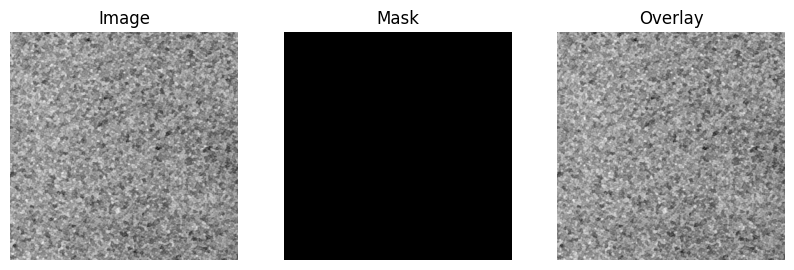

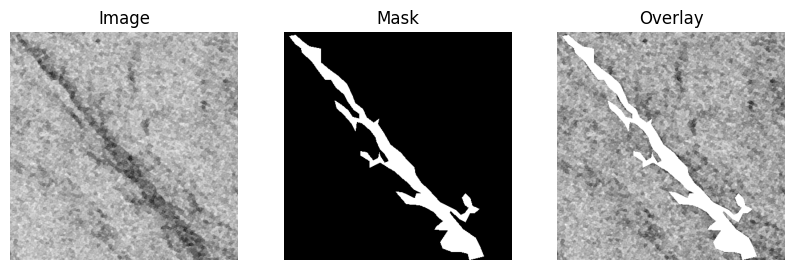

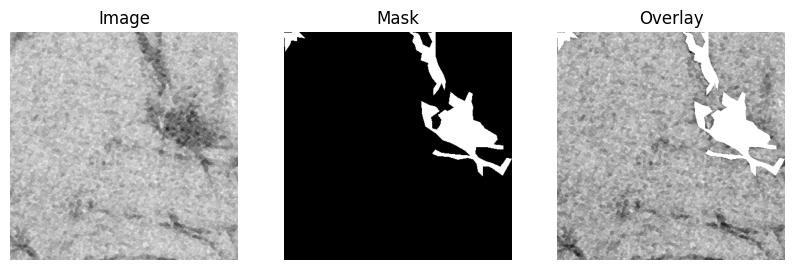

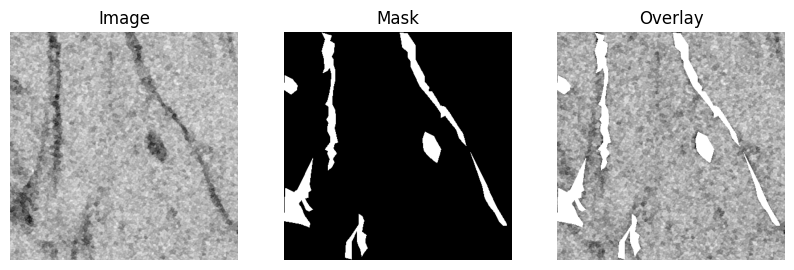

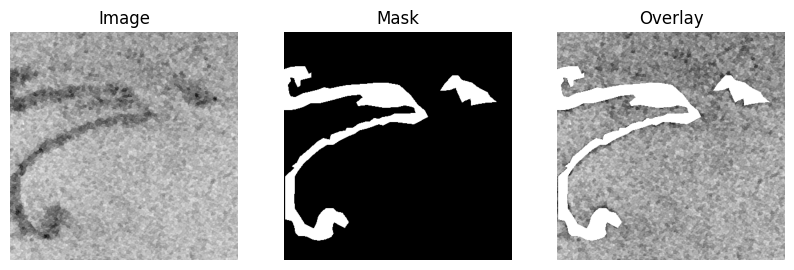

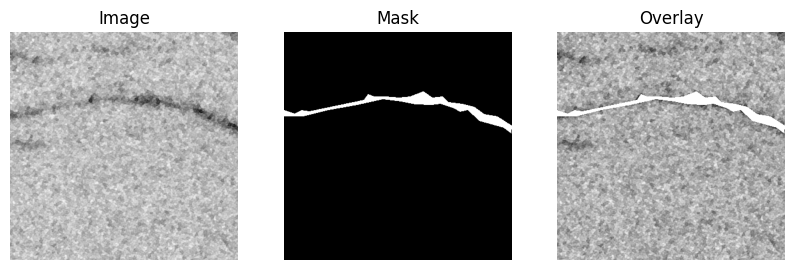

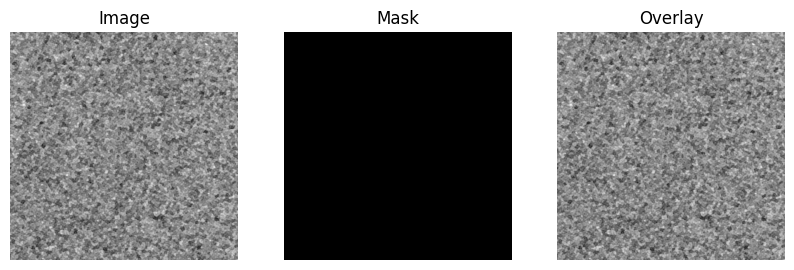

In [10]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

BASE = "/content/drive/MyDrive/oil_spill_project/data/sentinel/tiles"

def visualize_sample(split, n=3):
    img_dir = os.path.join(BASE, split, "images")
    mask_dir = os.path.join(BASE, split, "masks")

    # ONLY images that have masks
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith(".png")]
    if len(mask_files) == 0:
        print(f"No masks found for {split}")
        return

    samples = random.sample(mask_files, min(n, len(mask_files)))

    for name in samples:
        img_path = os.path.join(img_dir, name)
        mask_path = os.path.join(mask_dir, name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue

        overlay = img.copy()
        overlay[mask > 0] = 255  # highlight oil

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Overlay")
        plt.imshow(overlay, cmap="gray")
        plt.axis("off")

        plt.show()

# Run checks
visualize_sample("train", 3)
visualize_sample("val", 2)
visualize_sample("primary_test", 2)
